# DATA DESCRIPTION

***

- **T1w.nii**  --> structural T1-weighted image (3D)

***

- **mask.nii** --> brain mask, derived from a brain extraction procedure on the T1w data. This is a binary map, with the same dimension of the corresponding T1w

***

- **fMRI.nii** --> functional MRI data (4D), where each brain volume has been acquired multiple times. This is the fourth dimension of the fMRI data. The TR (repetition time, i.e. time between consecutive time points) is 3.5 sec.

***

- **MNI152_T1_2mm_brain.nii** --> common anatomical MNI space (MNI-2mm), 3D structure

***

- **Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.nii** --> reference brain atlas, consisting of 200 brain regions derived from a functional parcellation of the brain voxels/tissues, 3D structure of same dimension of anatomical MNI space

***

# PART 0
***
This part prior to the real analysis pipeline is performed to do some data exploration before starting with the real project. The aim is to gain familiarity with the data so that further examination will be much easier

- .nii format --> Neuroimaging Informatics Technology Initiative (NifTI): main standard used to archive, analyze and share brain scans (TAC, fMRI...) allowing the collection of volumetric images and temporal information in a unique file

In [4]:
import nibabel as nib
import os

In [10]:
DATA_PATH = os.path.join(os.getcwd(), "data")
T1_PATH = os.path.join(DATA_PATH, "T1w.nii")
MASK_PATH = os.path.join(DATA_PATH, "mask.nii")
FMRI_PATH = os.path.join(DATA_PATH, "fMRI.nii")
MNI_PATH = os.path.join(DATA_PATH, "MNI152_T1_2mm_brain.nii")
ATLAS_PATH = os.path.join(DATA_PATH, "Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.nii")
REGIONS_CSV_PATH = os.path.join(DATA_PATH, "Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.Centroid_RAS.csv")

In [ ]:
t1_img = nib.load(T1_PATH)
t1_hdr = t1_img.header
print(f"Type of variable t1_img: {type(t1_img)}")
print(f"Type of variable t1_hdr: {type(t1_hdr)}") # dictionary object, with keys and values
print(f"Shape of the T1 image: {t1_img.shape}")

Type of variable t1_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable t1_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the T1 image: (176, 256, 256)


In [21]:
print(t1_hdr)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 16384
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 176 256 256   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.          1.          0.9765625   0.97656244  0.          1.
  1.          1.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'6.0.3:b862cdd5'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : -0.022266022861003876
quatern_c       : -0.9872865676879883
quatern_d       : 0.1571

In [25]:
t1_dim = t1_hdr['dim'][:4]
print(f"Dimensions of the T1 image: {t1_dim}")

t1_data = t1_img.get_fdata()
print(f"Dimension of T1 img data: {t1_data.shape}")

Dimensions of the T1 image: [  3 176 256 256]
Dimension of T1 img data: (176, 256, 256)


In [40]:
mask = nib.load(MASK_PATH)
fmri_img = nib.load(FMRI_PATH)
mni_img = nib.load(MNI_PATH)
atlas_img = nib.load(ATLAS_PATH)

mask_data = mask.get_fdata()
fmri_data = fmri_img.get_fdata()
mni_data = mni_img.get_fdata()
atlas_data = atlas_img.get_fdata()

print(mask.shape)
print(fmri_img.shape)
print(mni_img.shape)
print(atlas_img.shape)
print(fmri_img.header['dim'])

(176, 256, 256)
(64, 64, 36, 200)
(91, 109, 91)
(91, 109, 91)
[  4  64  64  36 200   1   1   1]


if the dimension of the data is [176,256,256] then the last number represents the slices, 176 rows (x direction) and 256 columns (y-direction)

Text(0.5, 1.0, 'Single slice, n. 13')

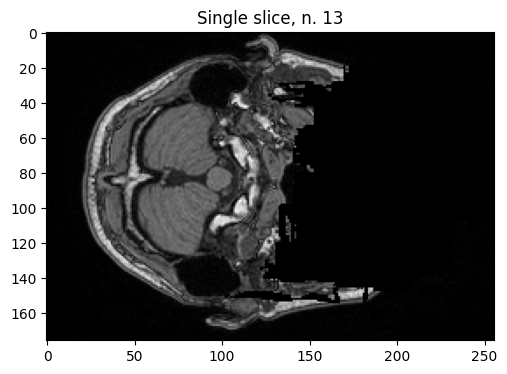

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Visualise a single representative axial slice - No Rotation
plt.figure(figsize=(6, 4))
z_slice = t1_data[:, :, 100]
plt.imshow(z_slice, cmap='gray', vmin=np.min(z_slice)), plt.grid(False)
plt.title('Single slice, n. '+str(13))

In [42]:
print(fmri_data.shape)
print(mni_data.shape)
print(atlas_data.shape)

(64, 64, 36, 200)
(91, 109, 91)
(91, 109, 91)


Text(0.5, 1.0, 'Single slice, n. 13')

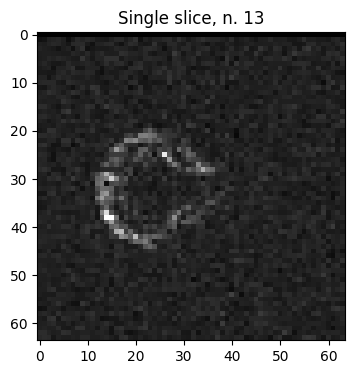

In [53]:
# Visualise a single representative axial slice - No Rotation
plt.figure(figsize=(6, 4))
z_slice = fmri_data[:,:, 35, 30]
plt.imshow(z_slice, cmap='gray', vmin=np.min(z_slice)), plt.grid(False)
plt.title('Single slice, n. '+str(13))

Text(0.5, 1.0, 'Single slice, n. 13')

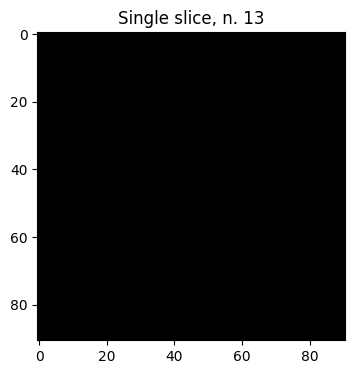

In [70]:
# Visualise a single representative axial slice - No Rotation
plt.figure(figsize=(6, 4))
z_slice = mni_data[:, 100, :]
plt.imshow(z_slice, cmap='gray', vmin=np.min(z_slice)), plt.grid(False)
plt.title('Single slice, n. '+str(13))

Text(0.5, 1.0, 'Single slice, n. 13')

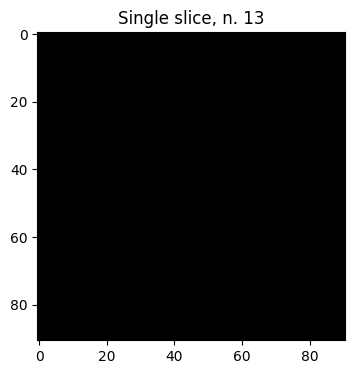

In [83]:
# Visualise a single representative axial slice - No Rotation
plt.figure(figsize=(6, 4))
z_slice = atlas_data[:, 9, :]
plt.imshow(z_slice, cmap='gray', vmin=np.min(z_slice)), plt.grid(False)
plt.title('Single slice, n. '+str(13))

Text(0.5, 1.0, 'Single slice, n. 13')

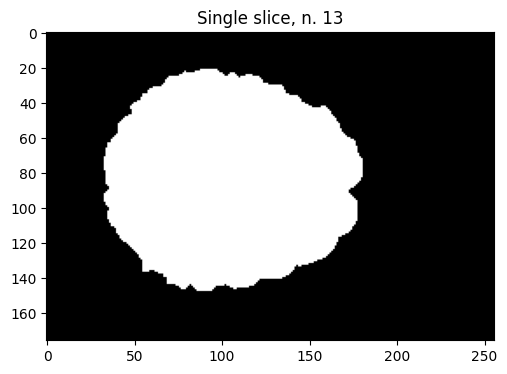

In [90]:
# Visualise a single representative axial slice - No Rotation
plt.figure(figsize=(6, 4))
z_slice = mask_data[:, :, 200]
plt.imshow(z_slice, cmap='gray', vmin=np.min(z_slice)), plt.grid(False)
plt.title('Single slice, n. '+str(13))